In [1]:
import pandas as pd
from pathlib import Path

CLEAN_FILE = Path(
    r"F:\pojects for github\NLP-Based Customer Review & Complaint Analyzer"
    r"\review-analyzer\data\clean\swiggy_reviews_clean_ipynb.csv"
)

df = pd.read_csv(CLEAN_FILE)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Shape:", df.shape)

Dataset loaded successfully.
Rows: 5000
Columns: 12
Shape: (5000, 12)


In [2]:
# Convert review timestamp to datetime
df["at"] = pd.to_datetime(df["at"], errors="coerce")

# Count reviews per day
daily_reviews = (
    df.set_index("at")
      .resample("D")
      .size()
      .reset_index(name="review_count")
)

print("Daily review volume:")
print(daily_reviews.to_string(index=False))

Daily review volume:
        at  review_count
2026-08-03           183
2026-08-04           467
2026-08-05           416
2026-08-06           384
2026-08-07           404
2026-08-08           465
2026-08-09           598
2026-08-10           411
2026-08-11           376
2026-08-12           447
2026-08-13           407
2026-08-14           442


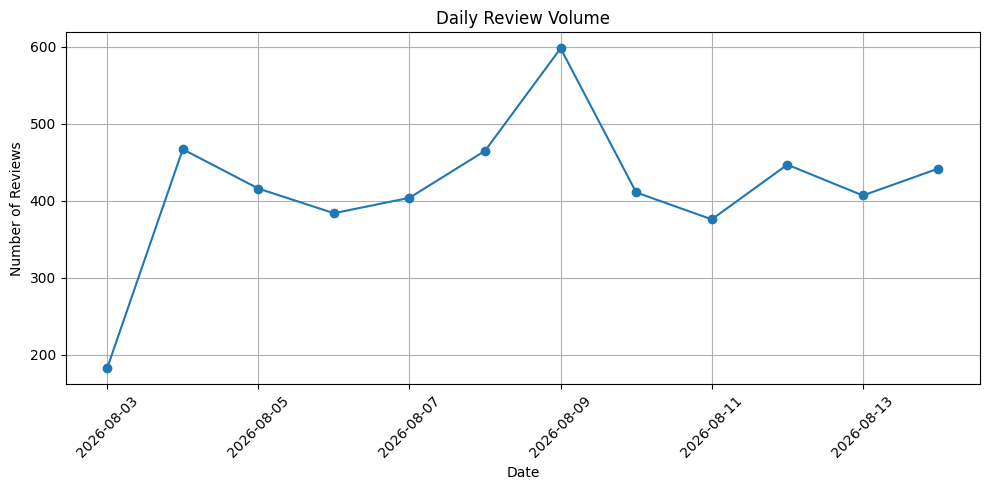

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    daily_reviews["at"],
    daily_reviews["review_count"],
    marker="o"
)

plt.title("Daily Review Volume")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [4]:
rating_counts = df["score"].value_counts().sort_index()

print("Rating distribution:")
print(rating_counts)

Rating distribution:
score
1    1587
2     149
3     213
4     445
5    2606
Name: count, dtype: int64


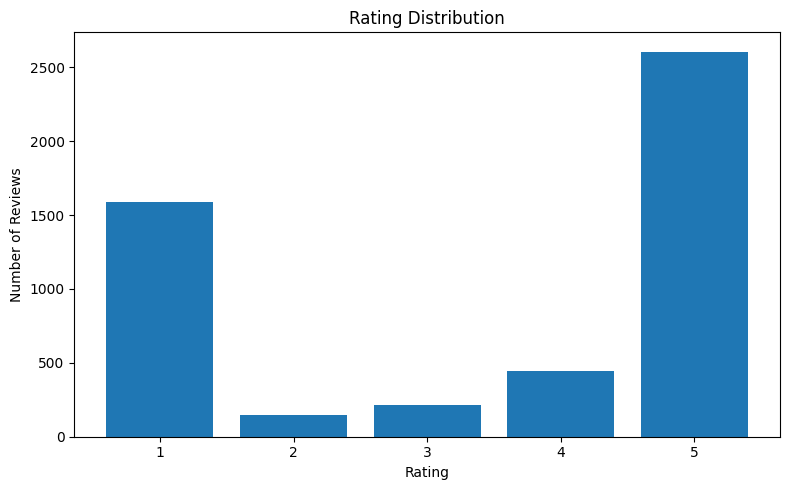

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [6]:
df["review_length"] = df["content"].astype(str).str.len()

print("Review length statistics:")
print(df["review_length"].describe())

Review length statistics:
count    5000.000000
mean       59.574400
std       110.799109
min         1.000000
25%         4.000000
50%        12.000000
75%        49.000000
max       500.000000
Name: review_length, dtype: float64
